In [34]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

A point at $p = (2, 1)$ needs to undergo these transformations **IN ORDER**:

1. **Scale** by $2\times$ in x-direction, $3\times$ in y-direction
2. **Rotate** by $45°$ counterclockwise
3. **Reflect** across the y-axis

In [27]:
# original point
p = np.array([2, 1])
S = np.array([[2, 0], [0, 3]])

R = np.array([
    [np.cos(np.deg2rad(45)), -np.sin(np.deg2rad(45))],
    [np.sin(np.deg2rad(45)), np.cos(np.deg2rad(45))]
])
M = np.array([[-1, 0], [0, 1]])

p_transform = M @ R @ S @ p # note: from last step to first step

In [28]:
p_transform

array([-0.70710678,  4.94974747])

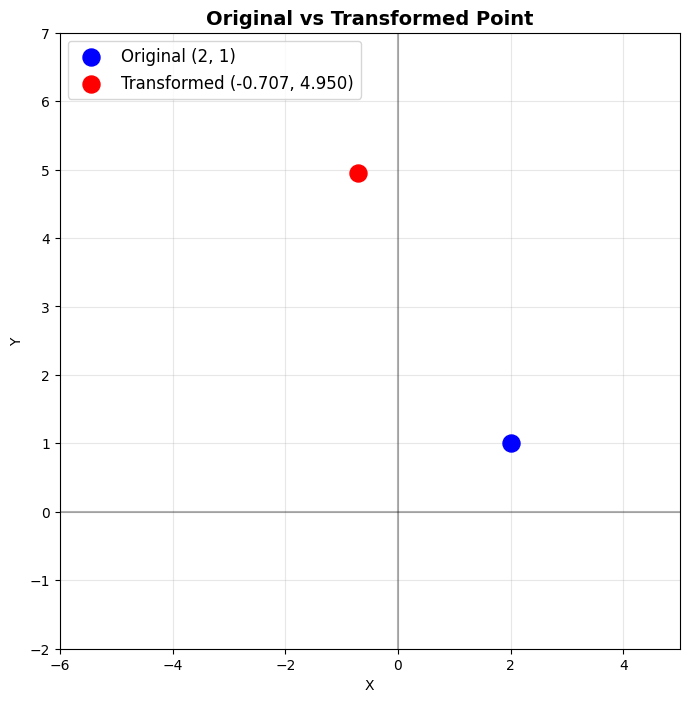

In [33]:
plt.figure(figsize=(8, 8))

plt.scatter(p[0], p[1], color='blue', s=150, label=f'Original ({p[0]}, {p[1]})', zorder=5)
plt.scatter(p_transform[0], p_transform[1], color='red', s=150, label=f'Transformed ({p_transform[0]:.3f}, {p_transform[1]:.3f})', zorder=5)

plt.axhline(y=0, color='black', linestyle='-', alpha=0.3)
plt.axvline(x=0, color='black', linestyle='-', alpha=0.3)
plt.grid(True, alpha=0.3)
plt.xlim(-6, 5)
plt.ylim(-2, 7)
plt.legend(fontsize=12)
plt.title('Original vs Transformed Point', fontsize=14, fontweight='bold')
plt.xlabel('X')
plt.ylabel('Y')
plt.show()

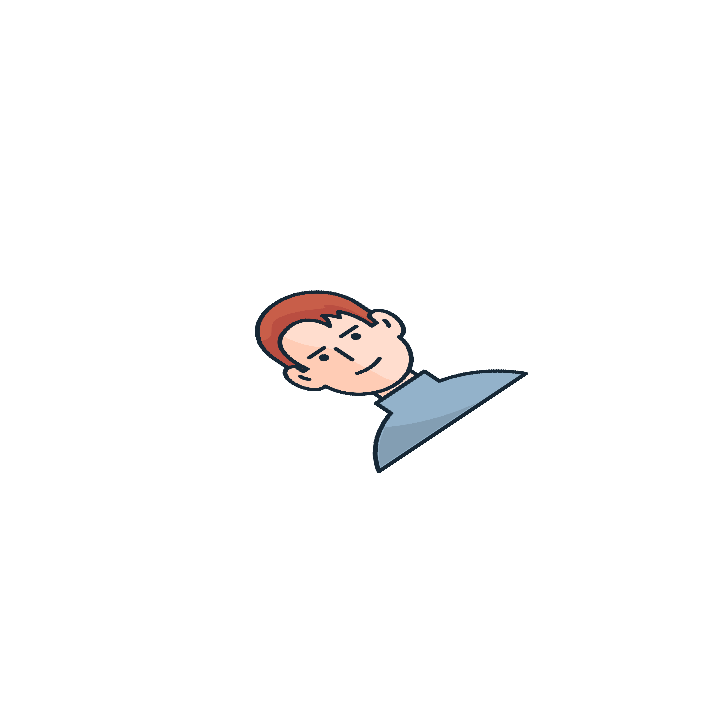

In [47]:
def transform_image(img_path, matrix, height=None, width=None):
    # load image
    img = Image.open(img_path)
    
    # resize image if needed
    h = height if height else img.height
    w = width if width else img.width
    
    img = img.resize((h, w))
    
    # convert img to array
    img_array = np.array(img)
    
    # center of image
    cx, cy = w/2, h/2
    
    # output array (larger to fit rotated image)
    new_size = int(np.linalg.norm(np.array([w, h]))) + 2 # int(np.sqrt(w**2 + h**2))
    rotated = np.zeros((new_size, new_size, 4), dtype=np.uint8)
    new_cx, new_cy = new_size//2, new_size//2
    
    # for each pixel in the ORIGINAL image (backward mapping=FILLS ALL PIXELS)
    for y in range(new_size):
        for x in range(new_size):
            # move to center
            p = np.array([x - new_cx, y - new_cy])
            
            # apply INVERSE rotation
            p_orig = matrix @ p
            
            # move back to original center
            orig_x = int(round(p_orig[0] + cx))
            orig_y = int(round(p_orig[1] + cy))
            
            # If within bounds, copy pixel
            if 0 <= orig_x < w and 0 <= orig_y < h:
                rotated[y, x] = img_array[orig_y, orig_x]

    return rotated

# show
image_path='../img/rotation_image.png'
transform_matrix = transform_image(img_path=image_path, matrix=M @ R @ S, height=200, width=200)
Image.fromarray(transform_matrix)

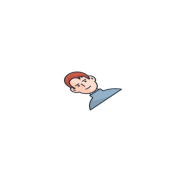

In [50]:
plt.figure(figsize=(6, 2))
plt.imshow(transform_matrix)
plt.axis('off')
plt.savefig('020_transform.png', dpi=200, bbox_inches='tight', pad_inches=0.1)
plt.show()